In [1]:
from sklearn.datasets import load_iris

iris = load_iris()

x = iris.data
y = iris.target

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

iris = load_iris()

x = iris.data
y = iris.target

df = pd.DataFrame(
    x,
    columns=iris.feature_names
)

df["target"] = y

df["species"] = df["target"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

df


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


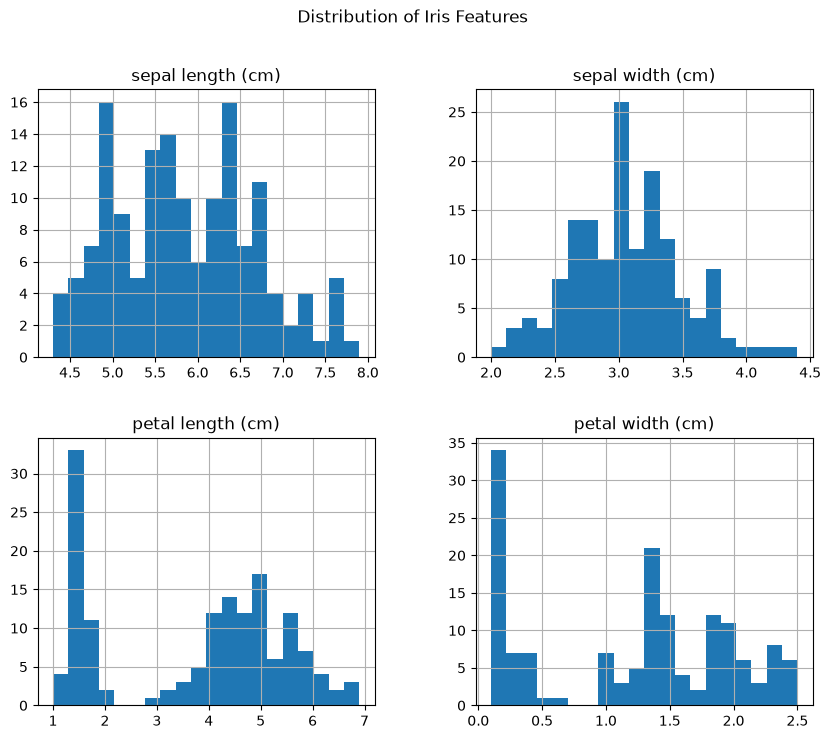

In [4]:
df[iris.feature_names].hist(
    figsize=(10, 8),
    bins=20
)

plt.suptitle("Distribution of Iris Features")
plt.show()

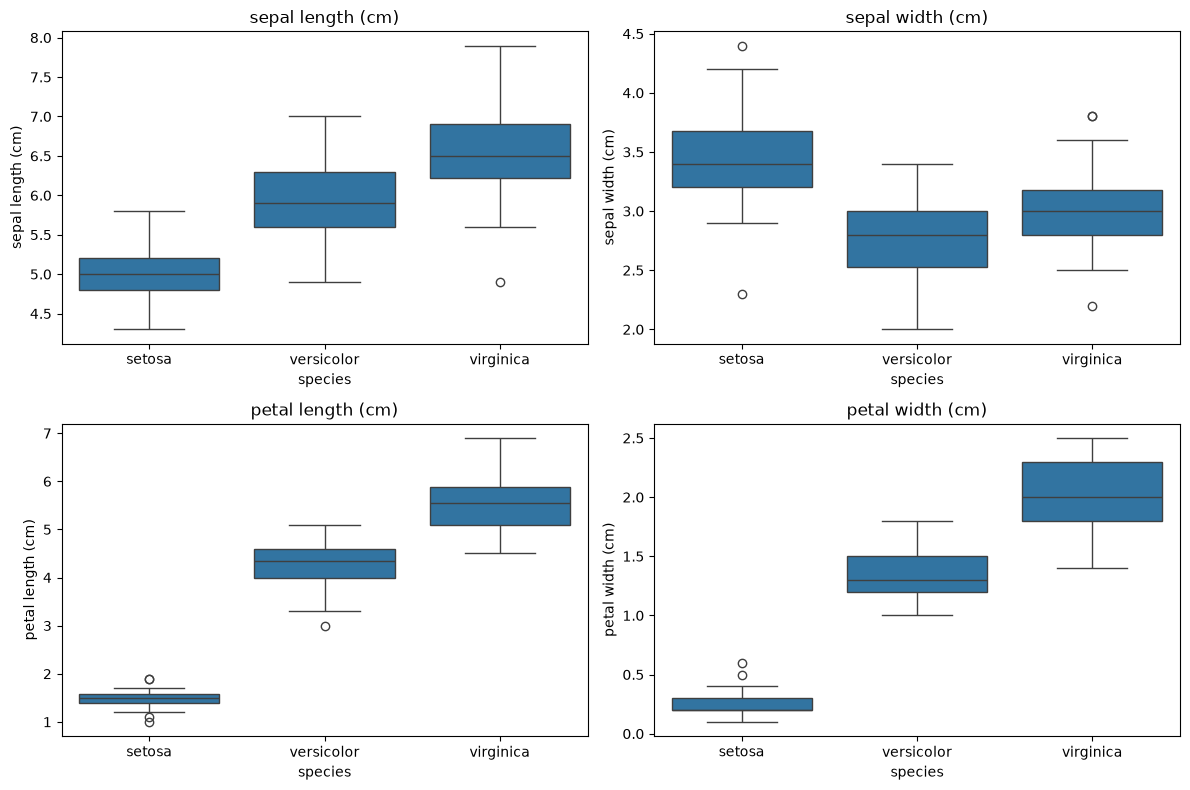

In [5]:
plt.figure(figsize=(12, 8))

for i, feature in enumerate(iris.feature_names, 1):

    plt.subplot(2, 2, i)

    sns.boxplot(
        data=df,
        x="species",
        y=feature
    )

    plt.title(feature)

plt.tight_layout()
plt.show()

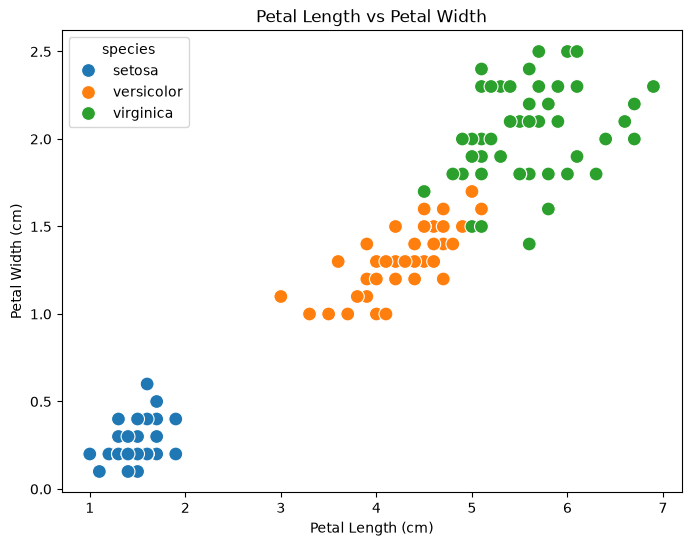

In [6]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species",
    s=100
)

plt.title("Petal Length vs Petal Width")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")

plt.show()

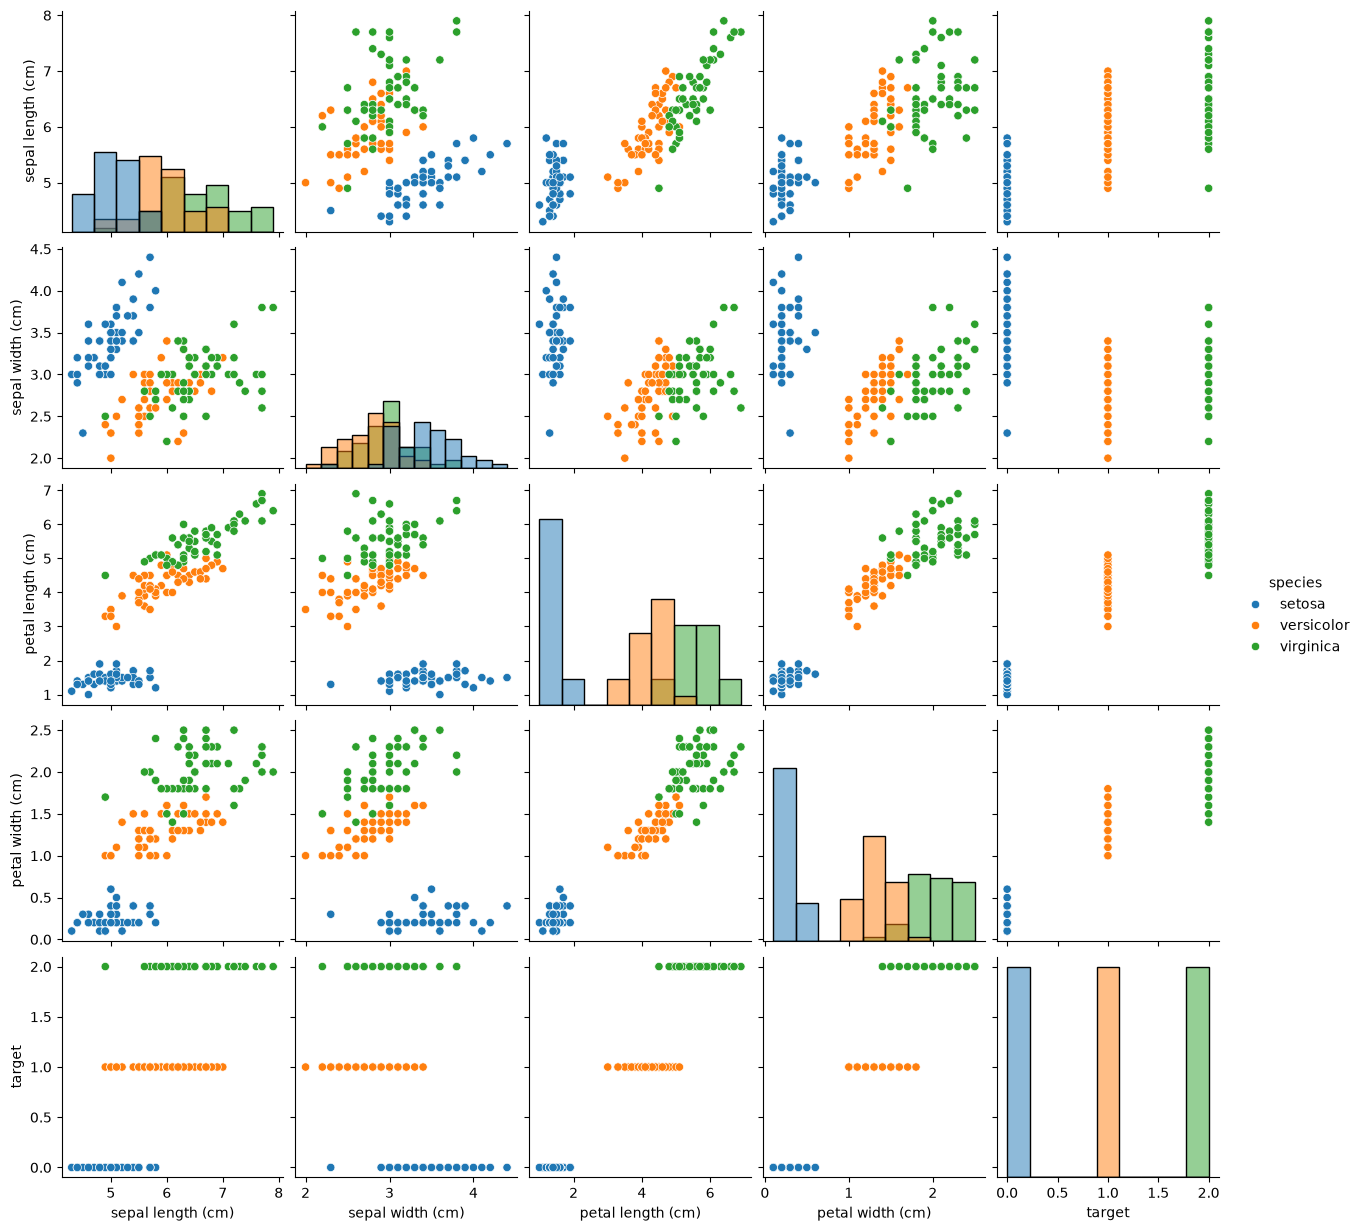

In [7]:
sns.pairplot(
    df,
    hue="species",
    diag_kind="hist"
)

plt.show()

In [8]:
correlation = df[iris.feature_names].corr()

print(correlation)

                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


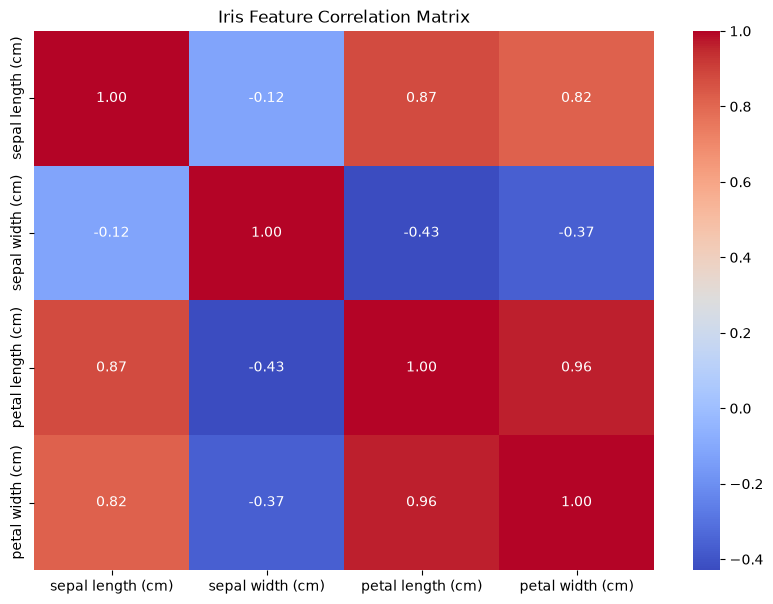

In [9]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Iris Feature Correlation Matrix")

plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
model = GaussianNB()

In [12]:
model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](3,)","[40.,40.,40.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](3,)","[0.33,0.33,0.33]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](3,)","[0,1,2]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,3.102e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](3, 4)","[[4.99,3.41,1.48,0.25], [5.93,2.75,4.25,1.32], [6.61,2.98,5.58,2.04]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](3, 4)","[[0.09,0.16,0.03,0.01], [0.22,0.09,0.19,0.03], [0.46,0.12,0.32,0.07]]"


In [13]:
y_pred = model.predict(X_test)

In [14]:
from sklearn.metrics import accuracy_score

print(
    "Accuracy : ",
    accuracy_score(y_test, y_pred)
)

Accuracy :  0.9666666666666667


In [15]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


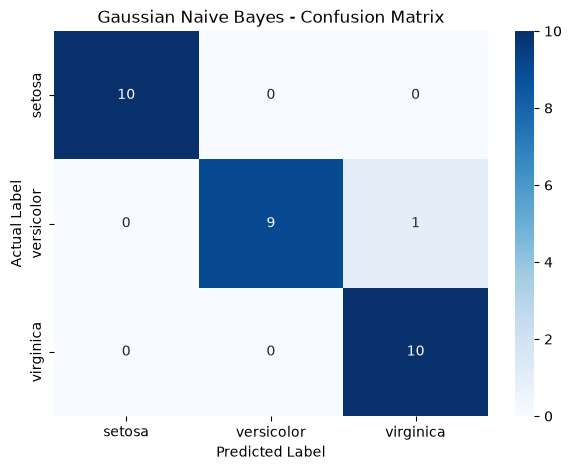

In [17]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Gaussian Naive Bayes - Confusion Matrix")

plt.show()

In [18]:
result_df = pd.DataFrame(
    X_test,
    columns=iris.feature_names
)

result_df["actual"] = y_test
result_df["predicted"] = y_pred

result_df["actual_species"] = result_df["actual"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

result_df["predicted_species"] = result_df["predicted"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

In [19]:
result_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),actual,predicted,actual_species,predicted_species
0,4.4,3.0,1.3,0.2,0,0,setosa,setosa
1,6.1,3.0,4.9,1.8,2,2,virginica,virginica
2,4.9,2.4,3.3,1.0,1,1,versicolor,versicolor
3,5.0,2.3,3.3,1.0,1,1,versicolor,versicolor
4,4.4,3.2,1.3,0.2,0,0,setosa,setosa


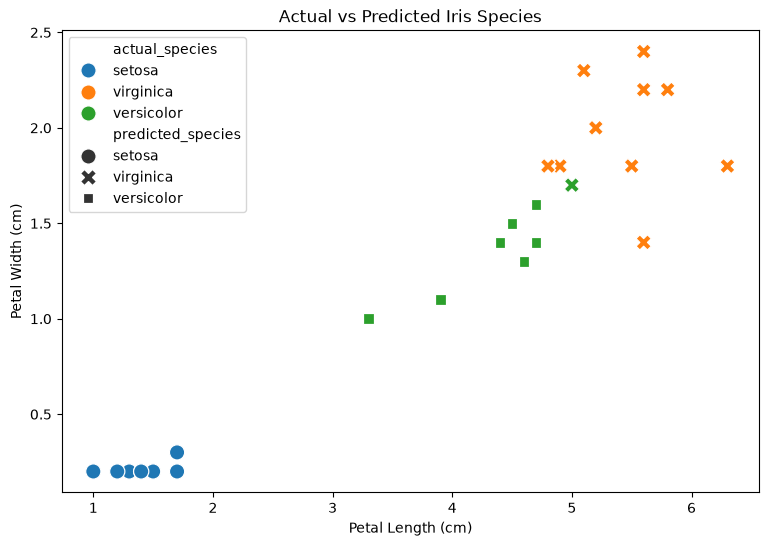

In [20]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=result_df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="actual_species",
    style="predicted_species",
    s=120
)

plt.title("Actual vs Predicted Iris Species")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")

plt.show()

In [21]:
y_probability = model.predict_proba(X_test)

print(y_probability[:5])

[[1.00000000e+000 2.10423610e-020 1.24046690e-025]
 [8.47878473e-143 8.77457913e-002 9.12254209e-001]
 [2.60594992e-036 9.99999490e-001 5.10180517e-007]
 [1.34650506e-036 9.99999567e-001 4.32500853e-007]
 [1.00000000e+000 6.60692071e-021 6.79224134e-026]]


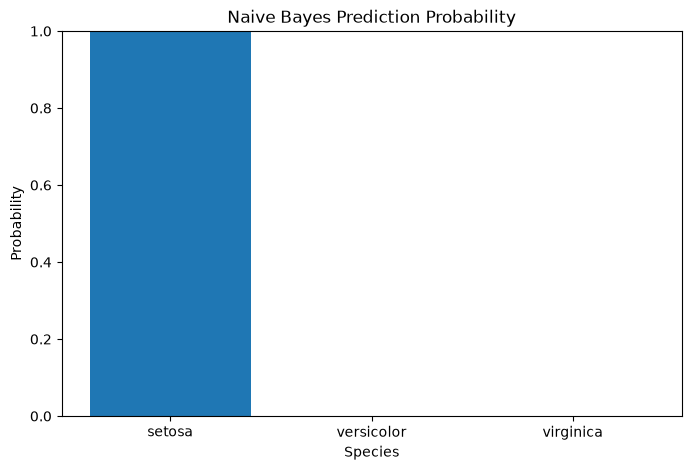

In [22]:
sample_index = 0

probabilities = model.predict_proba(
    X_test[sample_index].reshape(1, -1)
)[0]

plt.figure(figsize=(8, 5))

plt.bar(
    iris.target_names,
    probabilities
)

plt.xlabel("Species")
plt.ylabel("Probability")
plt.title("Naive Bayes Prediction Probability")

plt.ylim(0, 1)

plt.show()